<a href="https://colab.research.google.com/github/cnsalsabila/myXLSentimentAnalysis/blob/main/Week%202-3/EDA_myXL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA for Google Apps Review : myXL

## 1. Install Necessary Packages

In [1]:
!pip install pandas matplotlib seaborn nltk Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.2 MB/s eta 0:00:00


## 2. Import Required Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
import string
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.stem import WordNetLemmatizer

## 3. Download Stopwords

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


## 4. Upload & Load Dataset

In [4]:
from google.colab import files
uploaded = files.upload()

Saving df_myxl_preprocessed (2).csv to df_myxl_preprocessed (2).csv


In [5]:
import io

filename = list(uploaded.keys())[0]
df_myxl_rev = pd.read_csv(io.BytesIO(uploaded[filename]))

# Display the first few rows
df_myxl_rev.head()

,content,processed_text,score
0,MAKIN HARI BUKANNYA TAMBAH BAIK MALAH TAMBAH B...,burukkk mending bubarin xl layan buruk sinyal ...,1
1,signal jatingan buruk & harga paket internet m...,signal jatingan buruk harga paket internet mah...,2
2,pelayanan busuk.. masa daftar kuota di apk jad...,layan busuk daftar kuota aplikasi ilang xtra c...,1
3,BUSUK KALI .. MAU NGECLAIM KUOTA AKTIVASI AJA ...,busuk ngeclaim kuota aktivasi gabisa aplikasi ...,1
4,"tolong min ditempat ku sinyal full, kuota bany...",tolong min tempat ku sinyal full kuota dipake,1


## 5. Data Overview

In [10]:
# Convert 'at' column to datetime format (jika ada)
if 'at' in df_myxl_rev.columns:
    df_myxl_rev['at'] = pd.to_datetime(df_myxl_rev['at'])

# Display dataset info and first few rows
df_myxl_rev.info()
df_myxl_rev.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 959377 entries, 0 to 959376
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   content         959377 non-null  object
 1   processed_text  959376 non-null  object
 2   score           959377 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 22.0+ MB


,content,processed_text,score
0,MAKIN HARI BUKANNYA TAMBAH BAIK MALAH TAMBAH B...,burukkk mending bubarin xl layan buruk sinyal ...,1
1,signal jatingan buruk & harga paket internet m...,signal jatingan buruk harga paket internet mah...,2
2,pelayanan busuk.. masa daftar kuota di apk jad...,layan busuk daftar kuota aplikasi ilang xtra c...,1
3,BUSUK KALI .. MAU NGECLAIM KUOTA AKTIVASI AJA ...,busuk ngeclaim kuota aktivasi gabisa aplikasi ...,1
4,"tolong min ditempat ku sinyal full, kuota bany...",tolong min tempat ku sinyal full kuota dipake,1


## 6. Missing Values Analysis

In [11]:
missing_values = df_myxl_rev.isnull().sum()
print("Missing Values Summary:")
print(missing_values)

Missing Values Summary:
content           0
processed_text    1
score             0
dtype: int64


## 7. Review Score Distribution

/tmp/ipykernel_13075/1355058577.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_myxl_rev['score'], palette='viridis')


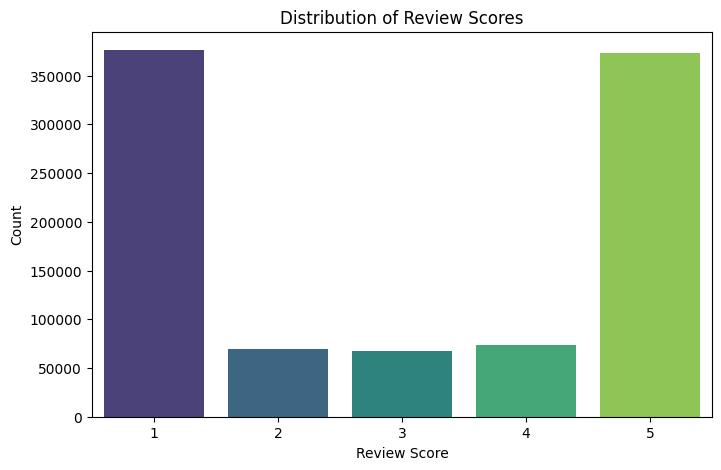

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(x=df_myxl_rev['score'], palette='viridis')
plt.title('Distribution of Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.show()

## 8. Review Score Proportion

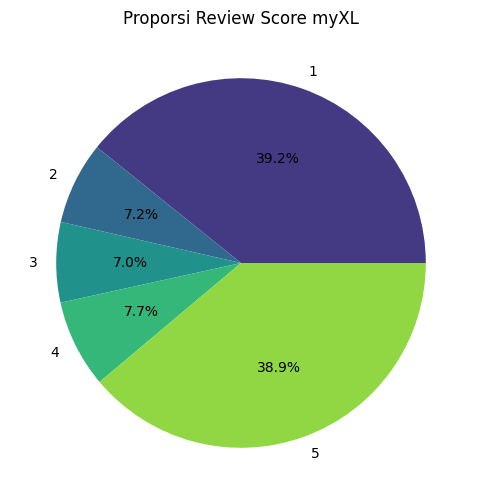

In [16]:
plt.figure(figsize=(6, 6))
df_myxl_rev['score'].value_counts().sort_index().plot.pie(
    autopct='%1.1f%%', colors=sns.color_palette('viridis', 5)
)
plt.title('Proporsi Review Score myXL')
plt.ylabel('')
plt.show()

## 9. Word Frequency Analysis

In [17]:
stop_words = set(stopwords.words('indonesian'))

# Combine all processed_text (sudah bersih dari tahap preprocessing)
all_reviews = " ".join(df_myxl_rev['processed_text'].dropna())
all_reviews = all_reviews.translate(str.maketrans("", "", string.punctuation))

# Tokenization and filtering words
words = all_reviews.split()
filtered_words = [word for word in words if word not in stop_words]

# Counting word occurrences
word_counts = Counter(filtered_words)
common_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Frequency'])

# Display most common words
print("Most Common Words in Reviews:")
print(common_words)

Most Common Words in Reviews:
        Word  Frequency
0         xl     232430
1   aplikasi     189844
2      bagus     170698
3      paket     138716
4     jaring     111614
5       beli     105604
6      kuota     104176
7     sinyal      92819
8      pulsa      74087
9       buka      72267
10    tolong      59249
11       oke      51619
12    lambat      49042
13      pake      39660
14    update      39495
15     mahal      37750
16        my      37662
17      myxl      37038
18     bonus      36578
19        gb      36325


## 10. Top Words Bar Chart

/tmp/ipykernel_13075/2059991512.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=common_words, x='Frequency', y='Word', palette='viridis')


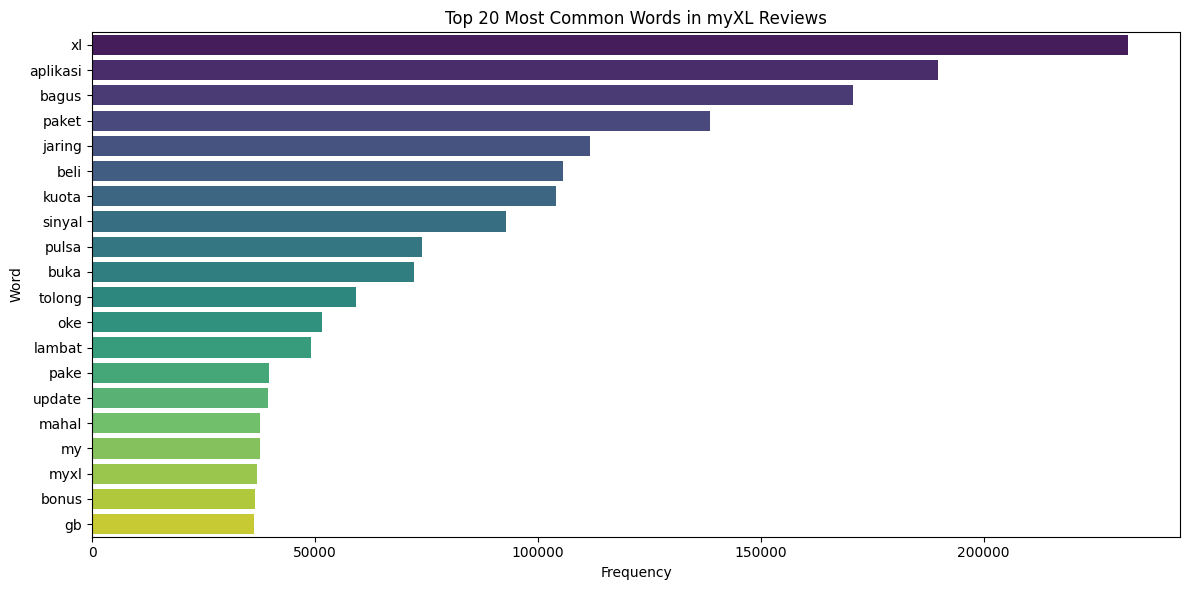

In [18]:
plt.figure(figsize=(12, 6))
sns.barplot(data=common_words, x='Frequency', y='Word', palette='viridis')
plt.title('Top 20 Most Common Words in myXL Reviews')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()